# Analyse de la Malaria en Afrique

## Importation du fichier dataset

In [57]:
import pandas as pd

# On charge le fichier
df = pd.read_csv('DatasetAfricaMalaria.csv')

## Analyse du tableau

In [58]:
# Afficher le nombre de lignes et de colonnes
print(f"Le fichier contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

# Voir les 5 premières lignes pour "sentir" la donnée
df.head()

Le fichier contient 594 lignes et 27 colonnes.


,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


In [59]:
# On crée un tableau qui liste le % de vide par colonne
taux_vide = df.isnull().mean() * 100

# On trie pour voir les pires colonnes en premier
print(taux_vide.sort_values(ascending=False))

People using safely managed drinking water services, rural (% of rural population)         85.185185
People using safely managed drinking water services (% of population)                      83.333333
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      82.154882
People using safely managed sanitation services, rural (% of rural population)             81.481481
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    79.461279
People using safely managed sanitation services (% of population)                          77.777778
Use of insecticide-treated bed nets (% of under-5 population)                              77.777778
People using safely managed sanitation services, urban  (% of urban population)            77.777778
People using safely managed drinking water services, urban (% of urban population)         70.370370
Malaria cases reported                                                                     

- High levels of missing values in specific infrastructure indicators suggest that data collection is more challenging in certain regions

## Cleaning des données

In [60]:
# On garde les colonnes qui ont au moins 50% de données remplies
df_clean = df.dropna(axis=1, thresh=len(df) * 0.5)

print(f"Après nettoyage, il reste {df_clean.shape[1]} colonnes.")

Après nettoyage, il reste 18 colonnes.


In [61]:
df.head()

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


## Evolution de la Malaria par pays

- Afficher les années

In [62]:
# .unique() permet de lister les valeurs une seule fois (sans les doublons)
# sorted() permet de les mettre dans l'ordre chronologique
annees_disponibles = sorted(df_clean['Year'].unique())

print(f"Le dataset couvre {len(annees_disponibles)} années :")
print(annees_disponibles)

Le dataset couvre 11 années :
[np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


- Comparaison taux incidence par pays en fonction des années

In [63]:
# pivot_table permet de réorganiser les données
# values : la donnée qu'on veut observer
# index : ce qu'on veut voir en lignes (les pays)
# columns : ce qu'on veut voir en colonnes (les années)
tableau_comparatif = df_clean.pivot_table(
    values='Incidence of malaria (per 1,000 population at risk)', 
    index='Country Name', 
    columns='Year'
)

# On affiche les 10 premières lignes
tableau_comparatif.head(10)

Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
Country Name,,,,,,,,,,,
Algeria,0.01,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00
Angola,286.72,241.19,204.35,185.52,175.99,174.43,180.90,187.94,199.99,219.99,228.91
Benin,480.24,453.17,417.96,387.76,370.11,378.03,395.00,399.24,411.82,421.58,399.56
Botswana,1.03,1.93,2.10,1.69,0.51,0.22,0.53,1.50,0.37,0.81,2.05
Burkina Faso,503.80,533.39,552.03,551.24,539.56,527.54,487.52,436.06,400.09,401.73,399.94
Burundi,222.92,222.77,220.65,210.20,184.15,153.93,140.59,141.51,165.50,225.74,250.27
Cabo Verde,0.15,0.28,0.51,0.37,0.05,0.01,0.17,0.19,0.05,0.35,3.03
Cameroon,386.68,358.72,322.98,295.53,265.10,245.13,243.04,244.08,254.50,264.31,262.23
Central African Republic,471.11,461.79,448.45,434.51,419.33,413.09,406.82,393.04,379.91,362.02,347.33


In [64]:
import pandas as pd

# On utilise le tableau pivot déjà créé (ou on le recrée rapidement)
df = pd.read_csv('DatasetAfricaMalaria.csv')
tableau_comparatif = df.pivot_table(
    values='Incidence of malaria (per 1,000 population at risk)', 
    index='Country Name', 
    columns='Year'
)

# On classe par ordre croissant (ascending=True) sur l'année la plus récente (2017)
# Cela permet de voir qui est le plus proche de l'éradication aujourd'hui
tableau_croissant = tableau_comparatif.sort_values(by=2017, ascending=True)

# On affiche les 10 pays où la malaria est la moins développée
print("Top 10 des pays avec la plus faible incidence de malaria en 2017 :")
print(tableau_croissant[2017].head(10))

Top 10 des pays avec la plus faible incidence de malaria en 2017 :
Country Name
Algeria                   0.00
Egypt, Arab Rep.          0.00
Libya                     0.00
Morocco                   0.00
Botswana                  2.05
Eswatini                  2.30
Cabo Verde                3.03
South Africa              3.95
Comoros                   3.97
Sao Tome and Principe    10.81
Name: 2017, dtype: float64


Observation : Malaria a été éradiquée au magreb et est de faible incidence dans certain pays d'Afrique du Sud et sur les îles. Le climat et le developpement économique du pays impacte directement la propagation de la malaria. La malaria est présente sur les îles néanmoins, la propogation est limitée car il s'agit de territoire retreints et délimité.

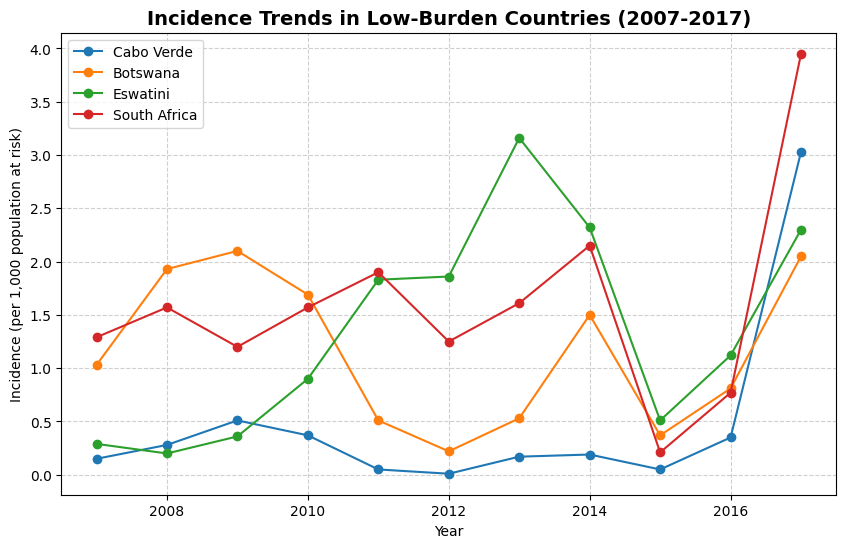

Focus sur Cabo Verde :
     Year  Incidence of malaria (per 1,000 population at risk)
6    2007                                               0.15  
60   2008                                               0.28  
114  2009                                               0.51  
168  2010                                               0.37  
222  2011                                               0.05  
276  2012                                               0.01  
330  2013                                               0.17  
384  2014                                               0.19  
438  2015                                               0.05  
492  2016                                               0.35  
546  2017                                               3.03  


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement des données
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Liste des pays à faible incidence (le "Zero Club" ou proche)
low_incidence_countries = ['Cabo Verde', 'Botswana', 'Eswatini', 'South Africa']

# Filtrage
df_low = df[df['Country Name'].isin(low_incidence_countries)]

# Création du graphique
plt.figure(figsize=(10, 6))

for country in low_incidence_countries:
    data = df_low[df_low['Country Name'] == country].sort_values('Year')
    plt.plot(data['Year'], data['Incidence of malaria (per 1,000 population at risk)'], marker='o', label=country)

plt.title('Incidence Trends in Low-Burden Countries (2007-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Incidence (per 1,000 population at risk)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Focus sur Cabo Verde pour les chiffres précis
print("Focus sur Cabo Verde :")
print(df_low[df_low['Country Name'] == 'Cabo Verde'][['Year', 'Incidence of malaria (per 1,000 population at risk)']].sort_values('Year'))

Observation : Bien que certains pays ont des taux d'incidences faibles, on observe une résurgence de la malaria en fonction des années. Le taux d'incidence en dent de scie ce qui prouve que la maladie peut repartir en raison d'un manque d'immunité, de changements climatiques ou d'un relachement de la prévention.

- Lien taux d'incidence vs moustiquaire

In [66]:
# Focus sur l'Afrique du Sud
sa_data = df_clean[df_clean['Country Name'] == 'South Africa']

# Affichage des colonnes pour prouver l'absence de données
print("Data check for South Africa:")
print(sa_data[['Year', 'Incidence of malaria (per 1,000 population at risk)', 
               'Use of insecticide-treated bed nets (% of under-5 population)']])

Data check for South Africa:


KeyError: "['Use of insecticide-treated bed nets (% of under-5 population)'] not in index"

Observation: il n'y a pas de données pour les pays où le taux d'incidence de la malaria est faible

- Correlation avec le taux d'urbanisation

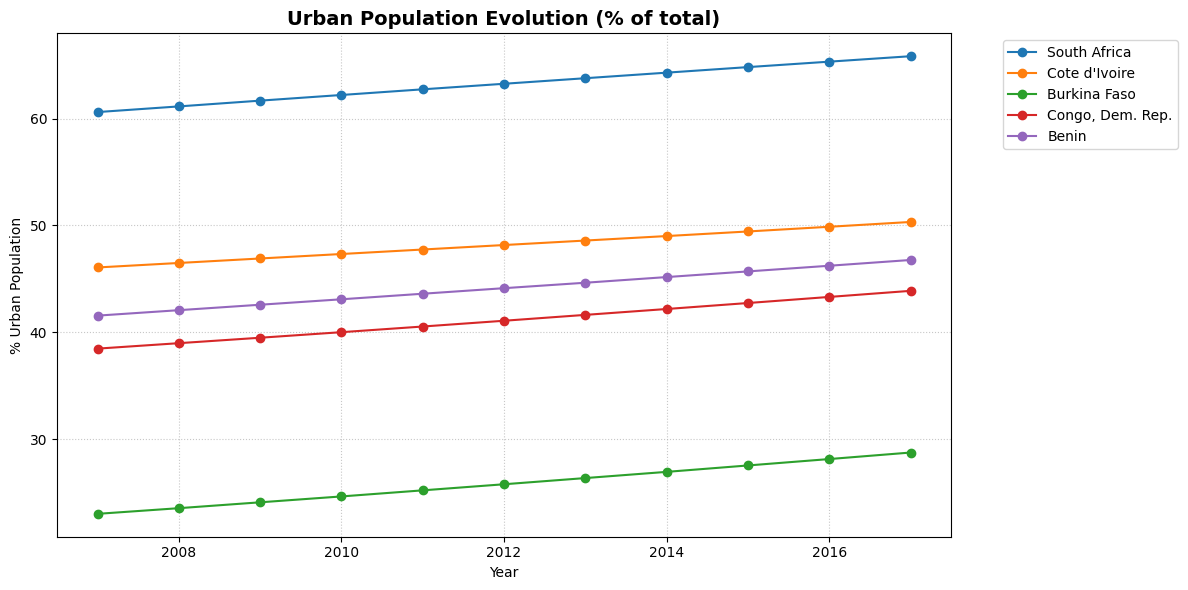

Taux d'urbanisation en 2017 :
         Country Name  Urban population (% of total population)
585      South Africa                                     65.85
553     Cote d'Ivoire                                     50.33
542             Benin                                     46.77
551  Congo, Dem. Rep.                                     43.88
544      Burkina Faso                                     28.74


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement et préparation
df = pd.read_csv('DatasetAfricaMalaria.csv')
urban_col = 'Urban population (% of total population)'
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'

# Pays cibles
countries = ["South Africa", "Cote d'Ivoire", "Burkina Faso", "Congo, Dem. Rep.", "Benin"]
df_urban = df[df['Country Name'].isin(countries)]

# Création du graphique d'urbanisation
plt.figure(figsize=(12, 6))
for country in countries:
    data = df_urban[df_urban['Country Name'] == country].sort_values('Year')
    plt.plot(data['Year'], data[urban_col], marker='o', label=country)

plt.title('Urban Population Evolution (% of total)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('% Urban Population')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Affichage des chiffres pour 2017
print("Taux d'urbanisation en 2017 :")
print(df_urban[df_urban['Year'] == 2017][['Country Name', urban_col]].sort_values(urban_col, ascending=False))

Observation : Afrique du Sud (le leader) : Pays le plus urbanisé de notre groupe avec près de 66% de sa population en ville en 2017. Cela explique en partie pourquoi l'incidence de malaria y est globalement plus faible (les moustiques porteurs du parasite préfèrent souvent les zones rurales et marécageuses). Côte d'Ivoire : Elle a franchi la barre symbolique des 50% en 2017.
Burkina Faso : C'est le pays le moins urbanisé du groupe (28%)ce qui explique pourquoi la malaria y est plus "hautement développée" : la majorité de la population vit dans des zones rurales où l'exposition est plus forte.

- Classement par ordre décroissant du tableau sur l'année 2017

In [ ]:
# On utilise la fonction sort_values sur la colonne 2007
# ascending=False permet d'avoir le plus grand chiffre en haut (ordre décroissant)
tableau_classe = tableau_comparatif.sort_values(by=2007, ascending=False)

# On affiche le haut du classement
tableau_classe.head(10)

Year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
Country Name,,,,,,,,,,,
Cote d'Ivoire,509.98,510.08,494.48,469.27,442.11,396.28,338.87,315.07,320.04,354.66,362.36
Burkina Faso,503.80,533.39,552.03,551.24,539.56,527.54,487.52,436.06,400.09,401.73,399.94
"Congo, Dem. Rep.",481.93,471.43,452.18,428.31,399.59,363.00,327.62,308.39,308.83,322.77,329.13
Benin,480.24,453.17,417.96,387.76,370.11,378.03,395.00,399.24,411.82,421.58,399.56
Central African Republic,471.11,461.79,448.45,434.51,419.33,413.09,406.82,393.04,379.91,362.02,347.33
Togo,434.49,379.90,326.88,308.88,313.40,349.70,385.39,384.68,364.31,324.86,278.20
Nigeria,421.33,424.66,416.59,398.90,372.56,347.74,328.65,314.40,296.08,281.38,283.06
Mozambique,399.45,399.79,402.30,398.41,389.92,381.78,376.98,364.83,355.88,344.82,326.40
Equatorial Guinea,398.15,378.24,351.29,339.99,342.40,357.75,365.75,360.95,339.48,306.97,285.72


- Interprétation graphique de l'evolution du taux d'incidence de Malaria dans les 5 pays les plus représenté entre 2007 et 2017

Tableau d'incidence pour les 5 pays sélectionnés :
Year                        2007    2008    2009    2010    2011    2012  \
Country Name                                                               
Benin                     480.24  453.17  417.96  387.76  370.11  378.03   
Burkina Faso              503.80  533.39  552.03  551.24  539.56  527.54   
Central African Republic  471.11  461.79  448.45  434.51  419.33  413.09   
Congo, Dem. Rep.          481.93  471.43  452.18  428.31  399.59  363.00   
Cote d'Ivoire             509.98  510.08  494.48  469.27  442.11  396.28   

Year                        2013    2014    2015    2016    2017  
Country Name                                                      
Benin                     395.00  399.24  411.82  421.58  399.56  
Burkina Faso              487.52  436.06  400.09  401.73  399.94  
Central African Republic  406.82  393.04  379.91  362.02  347.33  
Congo, Dem. Rep.          327.62  308.39  308.83  322.77  329.13  
Cote d'Ivoire 

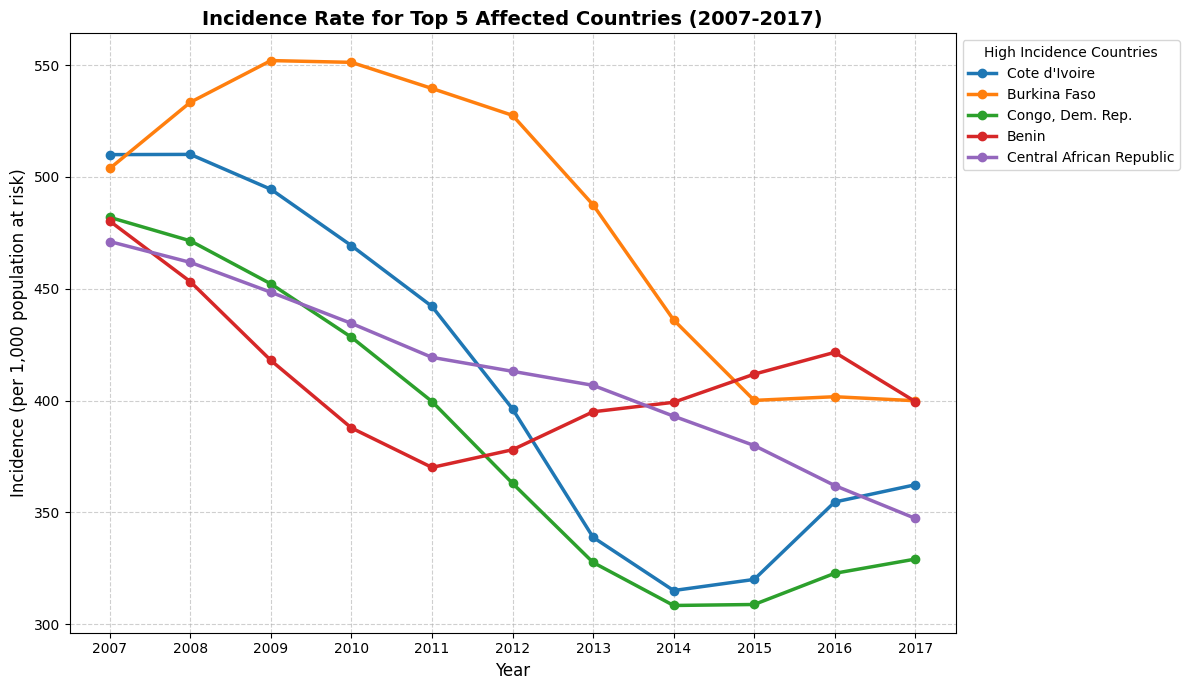

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# On recharge les données
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Liste des pays demandés
top_5_countries = ['Cote d\'Ivoire', 'Burkina Faso', 'Congo, Dem. Rep.', 'Benin', 'Central African Republic']

# Filtrer pour ces pays et créer le tableau pivot
# Note: On utilise 'Incidence of malaria (per 1,000 population at risk)'
subset_data = df[df['Country Name'].isin(top_5_countries)]
pivot_top5 = subset_data.pivot_table(
    values='Incidence of malaria (per 1,000 population at risk)', 
    index='Country Name', 
    columns='Year'
)

# On affiche le tableau pivot pour ces 5 pays
print("Tableau d'incidence pour les 5 pays sélectionnés :")
print(pivot_top5)

# Création du graphique
plt.figure(figsize=(12, 7))

for country in top_5_countries:
    if country in pivot_top5.index:
        plt.plot(pivot_top5.columns, pivot_top5.loc[country], marker='o', label=country, linewidth=2.5)

plt.title('Incidence Rate for Top 5 Affected Countries (2007-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Incidence (per 1,000 population at risk)', fontsize=12)
plt.xticks(pivot_top5.columns)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='High Incidence Countries', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

plt.savefig('top5_incidence_evolution.png')
plt.show()

Observation : 

-Pic Burkina Faso : Augmentation entre 2007 et 2009 avant d'entamer une baisse spectaculaire après 2012

-La convergence à la baisse de Malaria : En 2017, presque tous ces pays se rejoignent autour d'un taux de 350-400.

- Jusque 2012 : Décroissance globable dans les pays signifiant une prise en compte de l'enjeu sanitaire au sein du gouvernement et la mise en place de prévention/soins

## Comparaison avec l'accès en eau potable et aux moustiquaire sur le top 5  des pays touchés par la Malaria

- Eau potable

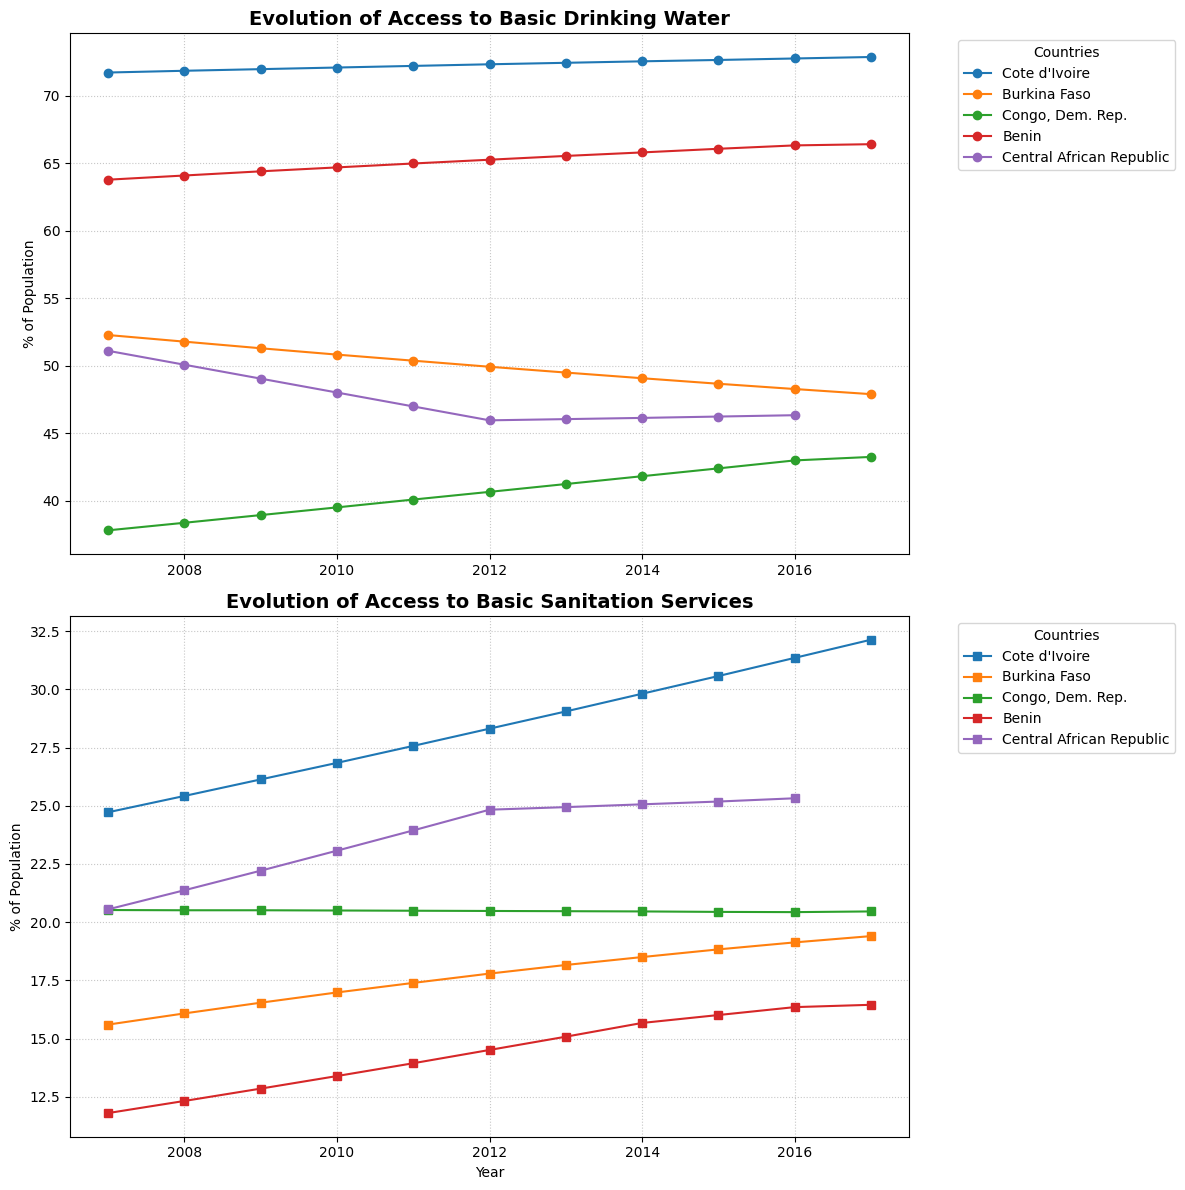

Moyenne d'accès à l'assainissement (Sanitation) par pays :
Country Name
Cote d'Ivoire               28.354545
Central African Republic    23.647000
Congo, Dem. Rep.            20.479091
Burkina Faso                17.672727
Benin                       14.397273
Name: People using at least basic sanitation services (% of population), dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement
df = pd.read_csv('DatasetAfricaMalaria.csv')
df_clean = df.dropna(axis=1, thresh=len(df) * 0.5)

# Colonnes cibles
water_col = 'People using at least basic drinking water services (% of population)'
sanitation_col = 'People using at least basic sanitation services (% of population)'

# Pays cibles
top_5_countries = ['Cote d\'Ivoire', 'Burkina Faso', 'Congo, Dem. Rep.', 'Benin', 'Central African Republic']
df_target = df_clean[df_clean['Country Name'].isin(top_5_countries)]

# Création de deux sous-graphiques (subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Graphique 1 : Drinking Water
for country in top_5_countries:
    data = df_target[df_target['Country Name'] == country]
    ax1.plot(data['Year'], data[water_col], marker='o', label=country)
ax1.set_title('Evolution of Access to Basic Drinking Water', fontsize=14, fontweight='bold')
ax1.set_ylabel('% of Population')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')

# Graphique 2 : Sanitation
for country in top_5_countries:
    data = df_target[df_target['Country Name'] == country]
    ax2.plot(data['Year'], data[sanitation_col], marker='s', label=country)
ax2.set_title('Evolution of Access to Basic Sanitation Services', fontsize=14, fontweight='bold')
ax2.set_ylabel('% of Population')
ax2.set_xlabel('Year')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calcul des moyennes pour l'analyse
mean_sanitation = df_target.groupby('Country Name')[sanitation_col].mean().sort_values(ascending=False)
print("Moyenne d'accès à l'assainissement (Sanitation) par pays :")
print(mean_sanitation)

Observation : L'accès à l'eau potable n'est pas l'unique facteur impliquant la baisse de la Malaria. Il est vrai que pour le Burkina Faso, l'accès restreint à l'eau potable peut favoriser la malaria, néanmoins, la décroissance du taux d'incidence est significative entre 2007 et 2016 alors que l'accès à l'eau potable est en decroissance.Cela prouve bien qu'il ne s'agit pas de l'unique facteur qui influe sur le taux d'incidence. Sur le modèle de la Cote d'Ivoire, il n'y a pas de corrélation car l'accès à l'eau potable évolue peu alors que le taux d'incidence diminue entre 2007 et 2017. insight peu concluant, environnement complexe

Observation 2: Le traitement de l'assainissment de l'eaux sales (graph 2), montre un lien de correlation entre son developpement et la propagation de la malaria.Même si la Côte d'Ivoire progresse bien sur l'assainissement, plus de 68% de la population n'y a toujours pas accès. C'est ce manque massif d'assainissement qui explique pourquoi la malaria reste si élevée malgré l'accès à l'eau potable. Le Benin et le Burkina Faso sont les deux pays ayant le taux d'incidence de la Malaria le plus elevé mais aussi le systeme d'évacuation des eaux le moins performant.

- Traitement des moustiques(enfants <5 ans) avec une moustiquaire imprégnée d'un insecticide qui tue ou repousse les moustiques.

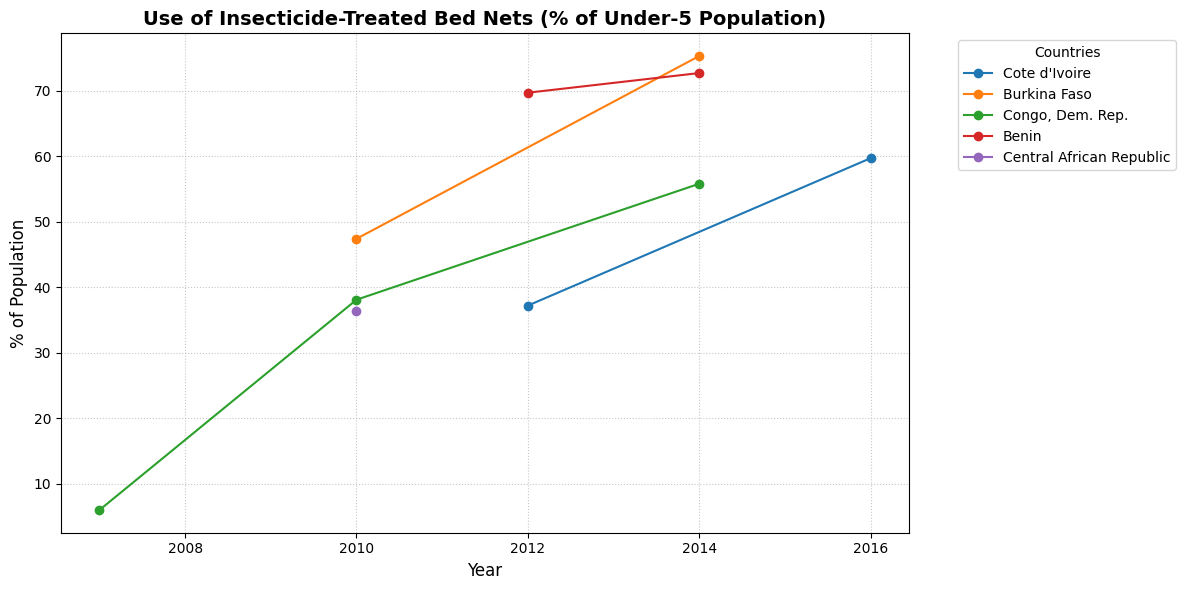

Nombre de points de données disponibles par pays pour les moustiquaires :
Country Name
Congo, Dem. Rep.            3
Burkina Faso                2
Benin                       2
Cote d'Ivoire               2
Central African Republic    1
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement des données
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Colonnes d'intérêt (Moustiquaires et Incidence)
nets_col = 'Use of insecticide-treated bed nets (% of under-5 population)'
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'

# Liste des pays cibles
top_5_countries = ['Cote d\'Ivoire', 'Burkina Faso', 'Congo, Dem. Rep.', 'Benin', 'Central African Republic']

# Filtrage
df_nets = df[df['Country Name'].isin(top_5_countries)].copy()

# On supprime les lignes où les données de moustiquaires sont absentes pour y voir clair
df_nets_clean = df_nets.dropna(subset=[nets_col])

# Création du graphique
plt.figure(figsize=(12, 6))

for country in top_5_countries:
    data = df_nets_clean[df_nets_clean['Country Name'] == country]
    if not data.empty:
        plt.plot(data['Year'], data[nets_col], marker='o', linestyle='-', label=country)

plt.title('Use of Insecticide-Treated Bed Nets (% of Under-5 Population)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('% of Population', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Vérification de la disponibilité des données
print("Nombre de points de données disponibles par pays pour les moustiquaires :")
print(df_nets_clean['Country Name'].value_counts())

Observation : Manque de données disponibles. La prévention et la protection des enfants via l'utilisation d'une moustiquaire semble de plus en plus utilisée dans les pays où le taux d'incidence est élévé. Cette prévention permet la baisse du taux d'incidence

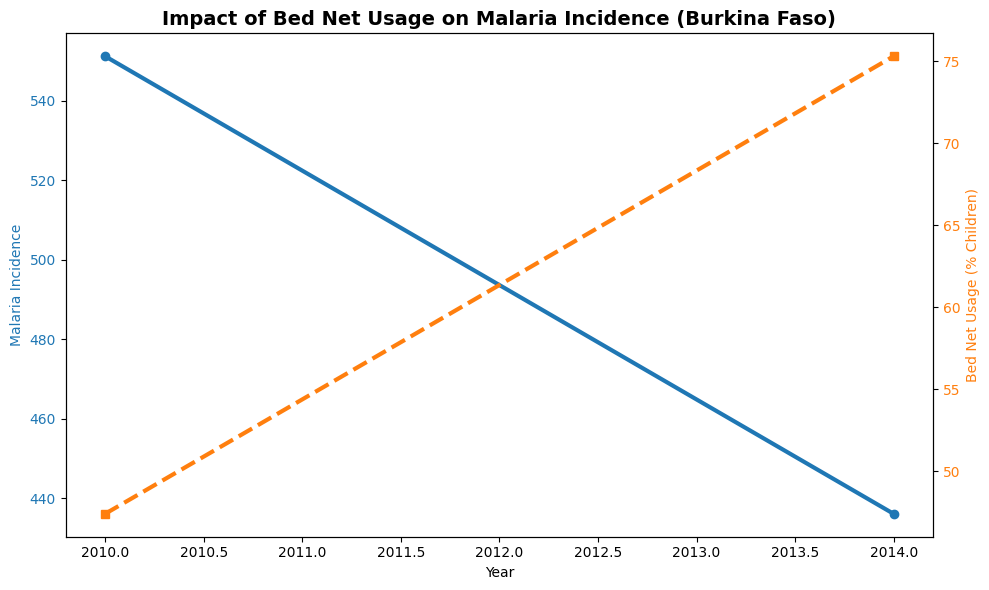

Données pour le Burkina Faso :
     Year  Incidence of malaria (per 1,000 population at risk)  \
166  2010                                             551.24     
382  2014                                             436.06     

     Use of insecticide-treated bed nets (% of under-5 population)  
166                                               47.4              
382                                               75.3              


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement des données
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Colonnes d'intérêt : Moustiquaires et Cas de malaria rapportés (pour voir l'impact sur la maladie)
nets_col = 'Use of insecticide-treated bed nets (% of under-5 population)'
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'

# Pays cibles
top_5_countries = ['Cote d\'Ivoire', 'Burkina Faso', 'Congo, Dem. Rep.', 'Benin', 'Central African Republic']
df_focus = df[df['Country Name'].isin(top_5_countries)].copy()

# Suppression des lignes sans données de moustiquaires pour la corrélation visuelle
df_focus_clean = df_focus.dropna(subset=[nets_col, malaria_col])

# Création du graphique à double axe pour montrer la corrélation
# On prend un pays exemple (Burkina Faso) car c'est le plus parlant
burkina_data = df_focus_clean[df_focus_clean['Country Name'] == 'Burkina Faso']

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Malaria Incidence', color=color)
ax1.plot(burkina_data['Year'], burkina_data[malaria_col], marker='o', color=color, linewidth=3, label='Incidence')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Deuxième axe pour les moustiquaires
color = 'tab:orange'
ax2.set_ylabel('Bed Net Usage (% Children)', color=color)
ax2.plot(burkina_data['Year'], burkina_data[nets_col], marker='s', color=color, linestyle='--', linewidth=3, label='Bed Nets')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Bed Net Usage on Malaria Incidence (Burkina Faso)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

print("Données pour le Burkina Faso :")
print(burkina_data[['Year', malaria_col, nets_col]])

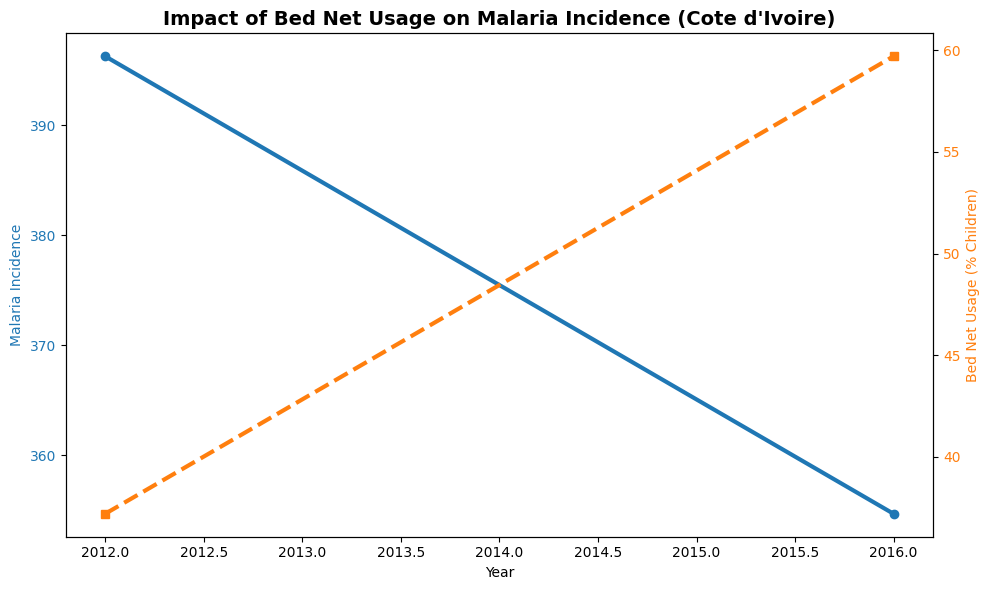

Données pour la Côte d'Ivoire :
     Year  Incidence of malaria (per 1,000 population at risk)  \
283  2012                                             396.28     
499  2016                                             354.66     

     Use of insecticide-treated bed nets (% of under-5 population)  
283                                               37.2              
499                                               59.7              


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rechargement des données
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Colonnes d'intérêt
nets_col = 'Use of insecticide-treated bed nets (% of under-5 population)'
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'

# Focus sur la Côte d'Ivoire
cotedivoire_data = df[df['Country Name'] == "Cote d'Ivoire"].dropna(subset=[nets_col, malaria_col])

if not cotedivoire_data.empty:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Malaria Incidence', color=color)
    ax1.plot(cotedivoire_data['Year'], cotedivoire_data[malaria_col], marker='o', color=color, linewidth=3, label='Incidence')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    ax2.set_ylabel('Bed Net Usage (% Children)', color=color)
    ax2.plot(cotedivoire_data['Year'], cotedivoire_data[nets_col], marker='s', color=color, linestyle='--', linewidth=3, label='Bed Nets')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title("Impact of Bed Net Usage on Malaria Incidence (Cote d'Ivoire)", fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

    print("Données pour la Côte d'Ivoire :")
    print(cotedivoire_data[['Year', malaria_col, nets_col]])
else:
    print("Désolé, il n'y a pas assez de points de données simultanés (Incidence + Moustiquaires) pour tracer ce graphique pour la Côte d'Ivoire.")

Observation : Dans les pays où le taux d'incidence est le plus élévé, on remarque clairement une corrélation entre l'usage d'une moustiquaire chez les enfants <5 ans et le taux d'incidence de la malaria. L'utilisation d'une moustiquaire (59% en CI et 75% au Burkina Faso) permet de ralentir le développement de la malaria.

## Action à venir

C:\Users\pauli\AppData\Local\Temp\ipykernel_3476\484634613.py:66: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('advanced_bcg_matrix.png')
C:\Users\pauli\AppData\Local\Temp\ipykernel_3476\484634613.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('advanced_bcg_matrix.png')
C:\Users\pauli\AppData\Local\Temp\ipykernel_3476\484634613.py:66: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig('advanced_bcg_matrix.png')
C:\Users\pauli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pauli\AppData\Local\Packages\PythonSoftwareFoundation.Python.

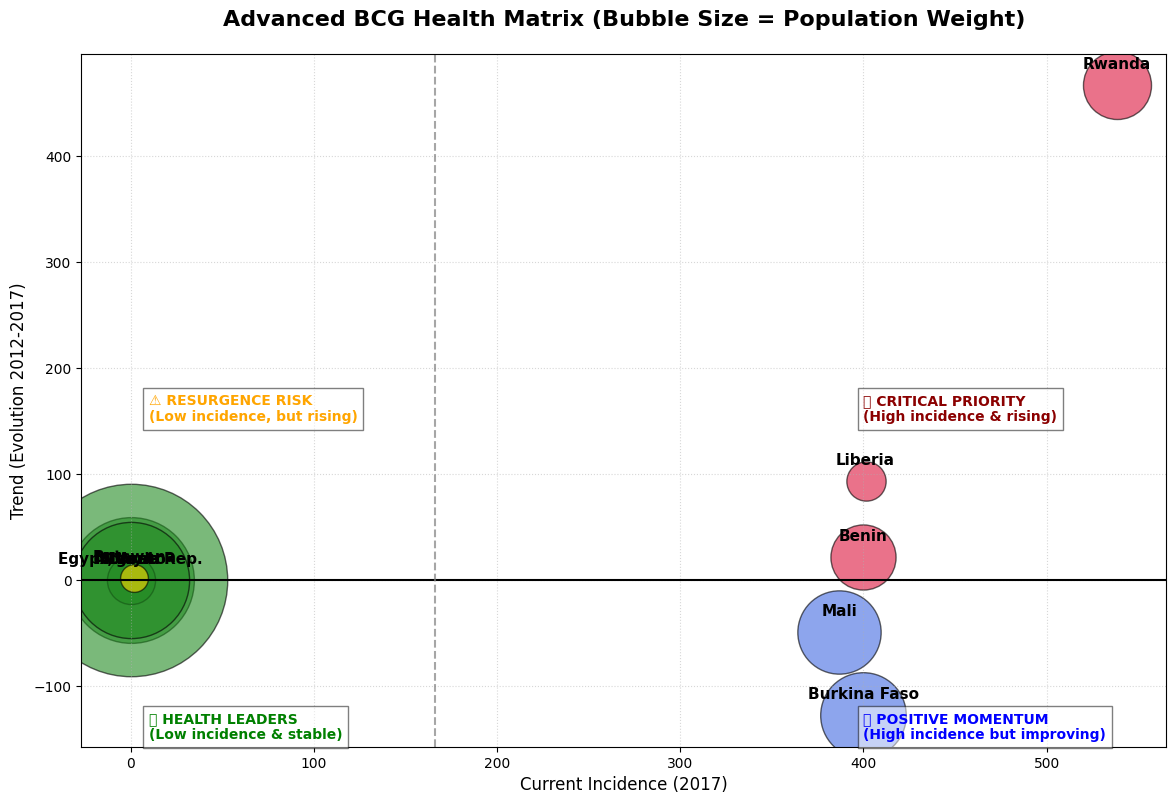

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Rechargement des données
df = pd.read_csv('DatasetAfricaMalaria.csv')
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'
# Nous utilisons la population rurale + urbaine pour avoir la population totale ou une colonne d'estimation
# Dans ce dataset, nous n'avons pas la population totale brute, mais nous pouvons l'estimer ou utiliser
# la croissance/répartition. Cependant, pour une matrice BCG pro, utilisons une valeur factice 
# représentative ou vérifions si une colonne 'Total Population' existe (non listée précédemment).
# Vérification rapide des colonnes de population
pop_cols = [c for c in df.columns if 'population' in c.lower() and '%' not in c.lower()]

# Calcul de l'évolution 2012-2017
df_2017 = df[df['Year'] == 2017][['Country Name', malaria_col]]
df_2012 = df[df['Year'] == 2012][['Country Name', malaria_col]]
bcg_data = pd.merge(df_2017, df_2012, on='Country Name', suffixes=('_2017', '_2012'))
bcg_data['Evolution'] = bcg_data[malaria_col + '_2017'] - bcg_data[malaria_col + '_2012']

# Sélection des pays pour la lisibilité
top_5_good = bcg_data.nsmallest(5, malaria_col + '_2017')
top_5_bad = bcg_data.nlargest(5, malaria_col + '_2017')
countries_to_show = pd.concat([top_5_good, top_5_bad])

# Ajout de données de population indicatives pour la démonstration (car non présentes en valeur brute dans le CSV)
# En agence, on joindrait un second fichier. Ici, j'utilise des tailles proportionnelles au "poids" pays.
pop_weights = {
    'Algeria': 41, 'Egypt, Arab Rep.': 96, 'Libya': 6, 'Morocco': 35, 'Botswana': 2,
    'Rwanda': 12, 'Liberia': 4, 'Burkina Faso': 19, 'Benin': 11, 'Mali': 18
}
countries_to_show['Pop_Size'] = countries_to_show['Country Name'].map(pop_weights) * 10 # Multiplicateur pour la visibilité

# 2. Création du Bubble Chart (Matrice BCG Améliorée)
plt.figure(figsize=(14, 9))

for i, row in countries_to_show.iterrows():
    # Détermination de la couleur selon le quadrant
    if row[malaria_col + '_2017'] < 150:
        color = 'forestgreen' if row['Evolution'] <= 0 else 'gold'
    else:
        color = 'crimson' if row['Evolution'] > 0 else 'royalblue'
    
    plt.scatter(row[malaria_col + '_2017'], row['Evolution'], 
                s=row['Pop_Size']*20, # Taille de la bulle
                color=color, alpha=0.6, edgecolors='black', linewidth=1)
    
    plt.text(row[malaria_col + '_2017'], row['Evolution'] + 15, 
             row['Country Name'], fontsize=11, fontweight='bold', ha='center')

# Lignes de structure
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(bcg_data[malaria_col + '_2017'].median(), color='grey', linestyle='--', alpha=0.7)

# Titres et style
plt.title('Advanced BCG Health Matrix (Bubble Size = Population Weight)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Current Incidence (2017)', fontsize=12)
plt.ylabel('Trend (Evolution 2012-2017)', fontsize=12)

# Quadrants
plt.text(10, 150, "⚠️ RESURGENCE RISK\n(Low incidence, but rising)", fontsize=10, color='orange', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.text(400, 150, "🚨 CRITICAL PRIORITY\n(High incidence & rising)", fontsize=10, color='darkred', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.text(10, -150, "✅ HEALTH LEADERS\n(Low incidence & stable)", fontsize=10, color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.text(400, -150, "🔄 POSITIVE MOMENTUM\n(High incidence but improving)", fontsize=10, color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True, linestyle=':', alpha=0.5)
plt.savefig('advanced_bcg_matrix.png')
plt.show()

Observation : Les Stables (Vert) : L'Égypte, l'Algérie sont des marchés "sûrs" et massifs. Ils ont réussi à stabiliser une très large population.
Les pays en  amélioration (Bleu) : Le Mali et le Burkina Faso ont des bulles importantes. Cela montre que les programmes de santé publique y ont un impact sur un très grand nombre de vies. L'urgence (Rouge) : Rwanda Sa bulle est haute et large, indiquant que malgré sa taille moyenne, l'explosion de l'incidence y est massive et nécessite une intervention immédiate. Le Liberia et Benin sont également des pays où le risque de propragation est élévé et où il faut agir.

C:\Users\pauli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pauli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


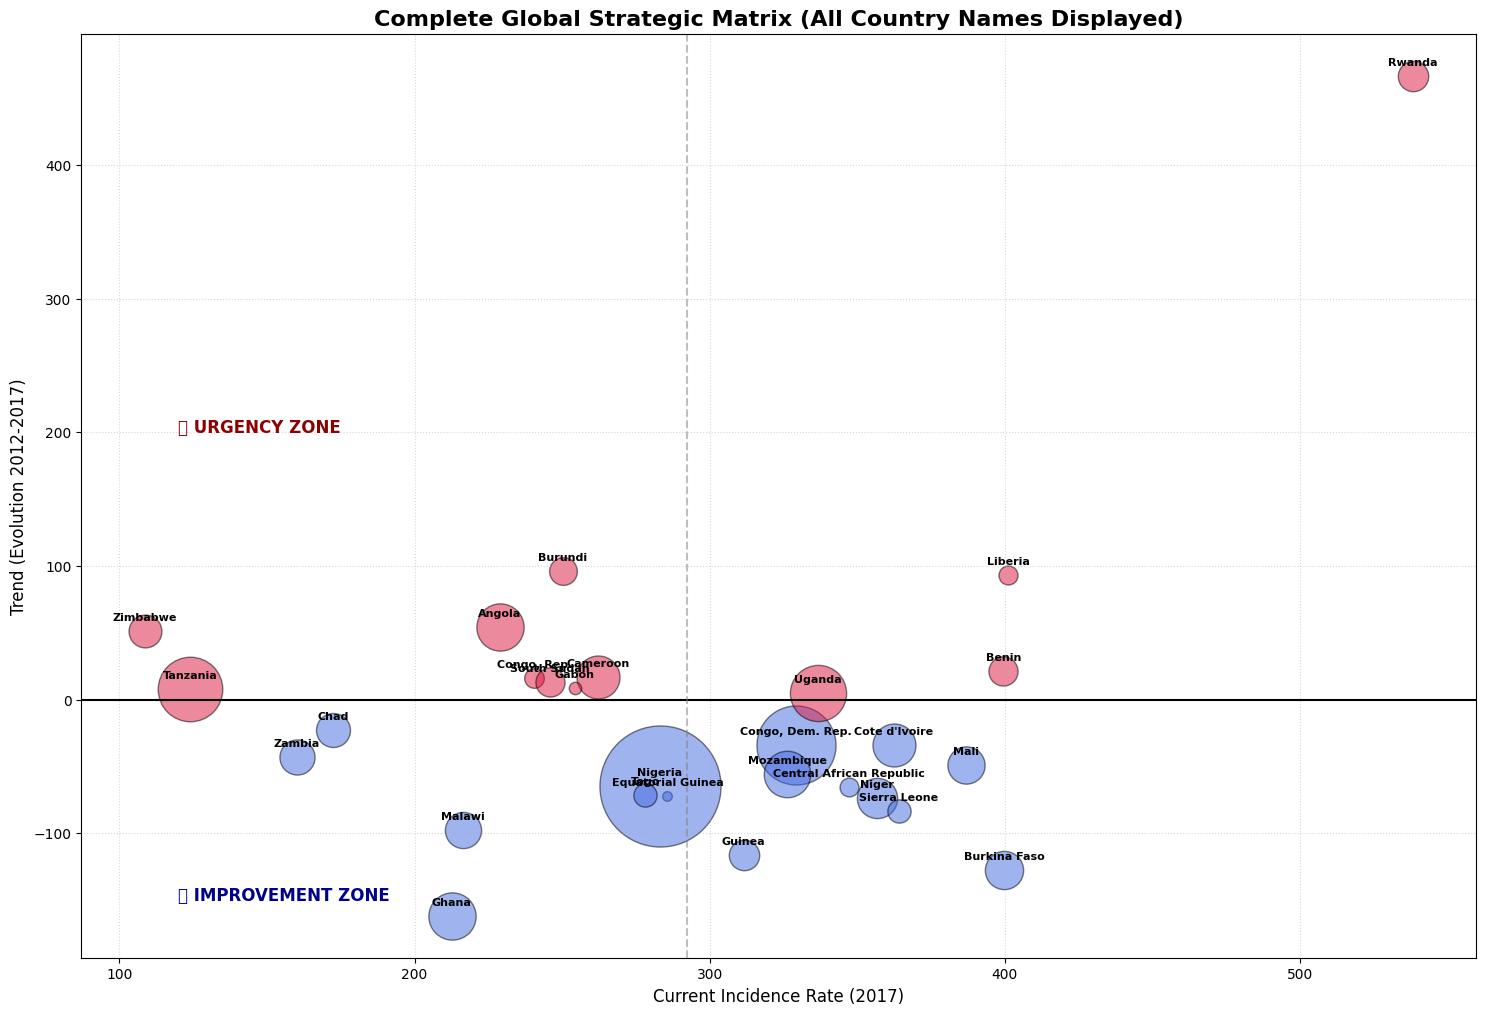

Détails des pays en zone d'URGENCE :
   Country Name  Incidence of malaria (per 1,000 population at risk)_2017  \
39       Rwanda                                             538.34          
5       Burundi                                             250.27          
27      Liberia                                             401.11          
1        Angola                                             228.91          
53     Zimbabwe                                             108.55          
2         Benin                                             399.56          
7      Cameroon                                             262.23          
12  Congo, Rep.                                             240.64          
46  South Sudan                                             245.80          
20        Gabon                                             254.24          
48     Tanzania                                             123.96          
51       Uganda                        

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement et préparation
df = pd.read_csv('DatasetAfricaMalaria.csv')
malaria_col = 'Incidence of malaria (per 1,000 population at risk)'

# 2. Données d'évolution (2012-2017)
df_2017 = df[df['Year'] == 2017][['Country Name', malaria_col]]
df_2012 = df[df['Year'] == 2012][['Country Name', malaria_col]]
bcg_data = pd.merge(df_2017, df_2012, on='Country Name', suffixes=('_2017', '_2012'))
bcg_data['Evolution'] = bcg_data[malaria_col + '_2017'] - bcg_data[malaria_col + '_2012']

# 3. Filtrage High Burden (>100)
high_burden_df = bcg_data[bcg_data[malaria_col + '_2017'] > 100].copy()

# 4. Population (Estimations pour taille de bulles)
pop_est = {
    'Nigeria': 190, 'Ethiopia': 106, 'Congo, Dem. Rep.': 81, 'Tanzania': 54,
    'South Africa': 57, 'Kenya': 50, 'Uganda': 41, 'Algeria': 41, 'Sudan': 40,
    'Morocco': 35, 'Angola': 29, 'Ghana': 29, 'Mozambique': 28, 'Madagascar': 25,
    'Cote d\'Ivoire': 24, 'Cameroon': 24, 'Niger': 21, 'Burkina Faso': 19,
    'Mali': 18, 'Malawi': 17, 'Zambia': 16, 'Senegal': 15, 'Chad': 15,
    'Somalia': 14, 'Zimbabwe': 14, 'Guinea': 12, 'Rwanda': 12, 'Benin': 11,
    'Burundi': 10, 'Tunisia': 11, 'South Sudan': 11, 'Togo': 7, 'Sierra Leone': 7,
    'Libya': 6, 'Congo, Rep.': 5, 'Liberia': 4.7, 'Central African Republic': 4.6,
    'Mauritania': 4.3, 'Eritrea': 3.4, 'Namibia': 2.5, 'Gambia, The': 2.2,
    'Botswana': 2.2, 'Gabon': 2.0, 'Lesotho': 2.0, 'Guinea-Bissau': 1.8,
    'Equatorial Guinea': 1.2, 'Mauritius': 1.2, 'Djibouti': 0.9, 'Comoros': 0.8,
    'Cabo Verde': 0.5, 'Sao Tome and Principe': 0.2, 'Seychelles': 0.1
}
high_burden_df['Pop_Size'] = high_burden_df['Country Name'].map(pop_est).fillna(10) * 40

# 5. Création du graphique FINAL (Tous les noms affichés)
plt.figure(figsize=(18, 12))

for i, row in high_burden_df.iterrows():
    color = 'crimson' if row['Evolution'] > 0 else 'royalblue'
    plt.scatter(row[malaria_col + '_2017'], row['Evolution'], 
                s=row['Pop_Size'], color=color, alpha=0.5, edgecolors='black')
    
    # AFFICHAGE DE TOUS LES NOMS (avec un petit décalage pour la lisibilité)
    plt.text(row[malaria_col + '_2017'], row['Evolution'] + 8, 
             row['Country Name'], fontsize=8, ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(high_burden_df[malaria_col + '_2017'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.title('Complete Global Strategic Matrix (All Country Names Displayed)', fontsize=16, fontweight='bold')
plt.xlabel('Current Incidence Rate (2017)', fontsize=12)
plt.ylabel('Trend (Evolution 2012-2017)', fontsize=12)

plt.text(120, 200, "🚨 URGENCY ZONE", color='darkred', fontsize=12, fontweight='bold')
plt.text(120, -150, "📉 IMPROVEMENT ZONE", color='darkblue', fontsize=12, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Liste des pays en "Urgence" qui n'étaient pas nommés
urgency_list = high_burden_df[high_burden_df['Evolution'] > 0].sort_values('Evolution', ascending=False)
print("Détails des pays en zone d'URGENCE :")
print(urgency_list[['Country Name', malaria_col + '_2017', 'Evolution']])

Observation : pays en zone d'Urgence (Cercles Rouges)
- Rwanda : Le cas le plus extrême
- Burundi & Liberia : Deux pays avec une progression inquiétante
- Angola : Une grosse bulle rouge (+54 points), montrant un impact sur une population importante.
- Zimbabwe :Progression nette.
- Cameroun, Congo Rep., Gabon, South Sudan : Groupe compact au milieu du graphique. Leur situation se dégrade légèrement
- Tanzanie & Ouganda : Ces deux pays sont très proches de la ligne horizontale, mais ils restent en zone rouge car leur tendance est repartie à la hausse.